In [ ]:
import torch 
import torch.nn.functional as F 
import matplotlib.pyplot as plt 
%matplotlib inline 


In [ ]:
words = open("names (1).txt" ,"r").read().splitlines()
words[:8]


In [ ]:
len(words)

In [ ]:
chars= sorted(list(set(''.join(words))))
mapping  = {c : i+1  for i,c in enumerate(chars)}
mapping['.'] = 0
reverse_mapping = {i:c for c,i in mapping.items()}
reverse_mapping


In [ ]:
block_size = 3
X , y = [] , []
for w in words:
    #print(w)
    context = [0]*block_size
    for ch in w + '.':
        ix = mapping[ch]
        X.append(context)
        y.append(ix)
        #print(''.join(reverse_mapping[i] for i in context) ,'---->' , reverse_mapping[ix])
        context = context[1:] + [ix]
        
X=torch.tensor(X)
y=torch.tensor(y)

In [ ]:
X.shape , y.shape

In [ ]:
C=torch.randn((27,2))


In [ ]:
F.one_hot(torch.tensor(5) , num_classes= 27).float() @ C

In [ ]:
#embedding X for 27 by 2 indexing
emb = C[X]


In [ ]:
w1 = torch.rand((6 ,100))
b = torch.rand(100)

In [ ]:
torch.cat([emb[: , 0 , :] , emb[: , 1 , :] , emb[: , 2 , :] ] , 1).shape

In [ ]:
#this work when we change the block size 
torch.cat(torch.unbind(emb , 1) , 1).shape

In [ ]:
h = torch.tanh(emb.view(-1 , 6) @ w1 + b)
h


In [ ]:
#creating the final layer or output layer
W2 = torch.randn((100 , 27))
b2 = torch.randn(27)

In [ ]:
logits = h @ W2  + b2

In [ ]:
logits

In [ ]:
counts = logits.exp()

In [ ]:
prob = counts / counts.sum(1 , keepdim=True)
prob[0].sum()

In [66]:
#bulid the datasets 
import random

def Build_dataset(words):
    block_size = 3
    X , y = [] , []
    for w in words:
        #print(w)
        context = [0]*block_size
        for ch in w + '.':
            ix = mapping[ch]
            X.append(context)
            y.append(ix)
            #print(''.join(reverse_mapping[i] for i in context) ,'---->' , reverse_mapping[ix])
            context = context[1:] + [ix]
        
    X=torch.tensor(X)
    y=torch.tensor(y)
    return X ,y

random.seed(42)
random.shuffle(words)
n1 =int(0.8*len(words))
n2 =int(0.9*len(words))

Xtr , ytr = Build_dataset(words[:n1])
Xdv , ydv = Build_dataset(words[n1:n2])
Xts , yts = Build_dataset(words[n2:])

In [100]:
g=torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10) , generator=g)
W1= torch.randn((30,200) , generator=g)
b1 = torch.rand(200 , generator=g)
W2 = torch.randn((200 , 27) , generator=g)
b2 = torch.randn(27 , generator=g)

parameters = [C,W1,b1,W2,b2]

In [101]:
sum(p.nelement() for p in parameters)

11897

In [102]:
for p in parameters:
    p.requires_grad = True

In [103]:
# lre= torch.linspace(-3 , 0 , 1000)
# lrs = 10**lre

lossi = []
stepi= []

In [112]:

for i in range(50000):
    #minibatch
    ix = torch.randint(0 , Xtr.shape[0] , (32,))

    #forward pass 
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1 , 30) @ W1 + b1)
    logits = h @ W2  + b2
    loss =F.cross_entropy(logits , ytr[ix])
    
    #backward pass 
    for p in parameters:
        p.grad= None
    loss.backward()

    #update 
    lr = 0.01
    for p in parameters:
        p.data += - lr* p.grad
    # lri.append(lre[i])
    lossi.append(loss.log10().item()) 
    stepi.append(i)


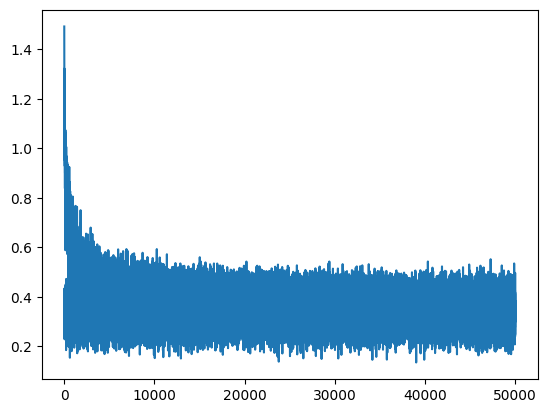

In [113]:
plt.plot(stepi , lossi)

In [114]:
emb = C[Xdv]
h = torch.tanh(emb.view(-1 , 30) @ W1 + b1)
logits = h @ W2  + b2
loss =F.cross_entropy(logits , ydv)
loss 

tensor(2.2116, grad_fn=<NllLossBackward0>)

In [115]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1 , 30) @ W1 + b1)
logits = h @ W2  + b2
loss =F.cross_entropy(logits , ytr)
loss 

tensor(2.1580, grad_fn=<NllLossBackward0>)